# Example notebook: Fisher forecast 

Authors: Sambit Giri, Adélie Gorce, Ian Hothi

Date: June 2025

In this notebook, we show how to obtain Fisher results from statistics pre-computed on the simulation dataset with the `compute_statistic` script.

In [1]:
import numpy as np
import h5py
import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
import corner

import os
import numpy as np

In [2]:
# Folder where the data is stored
ddir = '/data/cluster/agorce/SKA_chapter_simulations/'

In [3]:
# Astro params
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']
nparams = len(params)
# parameter values for fiducial simulation
fid = [pow(10,4.7),15,30]

In [4]:
# SKA obs parameters
# obs_time = 1000.     # total observation hours
obs_time_array = [100., 1000., 1000.]
layout_array = ['AAstar', 'AAstar', 'AA4']

In [5]:
label_moments = ['Mean', 'Variance', 'Skewness', 'Kurtosis']

## Fisher Matrix

Under the assumption that the likelihood is a multivariate Gaussian (mean vectors are sufficient information for the covariance matrix), the Fisher matrix is defined as:

$$F^\theta_{ij} = \frac{\partial \textbf{S}}{\partial\theta_i} \mathbf{\Sigma}^{-1} \frac{\partial \textbf{S}}{\partial\theta_j},$$

where  $\frac{\partial \textbf{S}}{\partial\theta_i}$ is the change in statistic S under a change in paramrter i of $\partial\theta_j$. Here, $\mathbf{\Sigma}$ is the the covariance matrix, given my the fiducial simulation set.


Plot the resulting Gaussian distribution with appropriate covariance

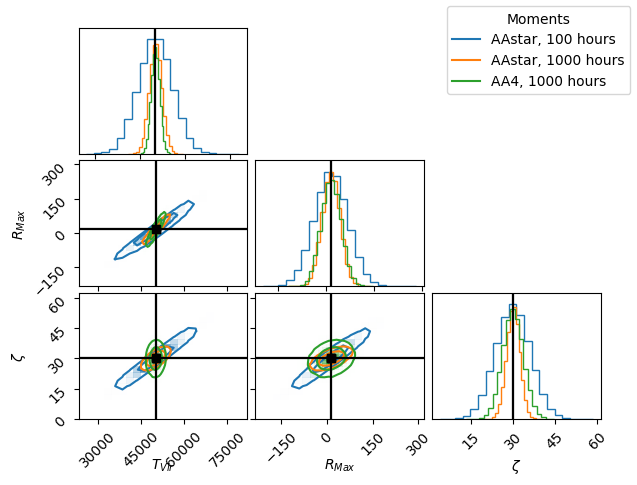

In [6]:
nrand = 100000

fig, axes = plt.subplots(nparams, nparams)
for j, (obs_time, layout) in enumerate(zip(obs_time_array, layout_array)):
    covmat = np.loadtxt(f'./output/posterior_covariance_matrix_{layout}_{int(obs_time)}hours_moments.txt')
    fisher_data = np.random.multivariate_normal(fid, covmat, size=nrand)
    _ = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truth_color='k',
    truths=fid,
    color=f'C{j}',
    fig=fig)
    axes[0, 0].plot([], [], label=f'{layout}, {int(obs_time)} hours', color=f'C{j}', linestyle='-')
fig.legend(loc='upper right', fontsize=10, title='Moments')

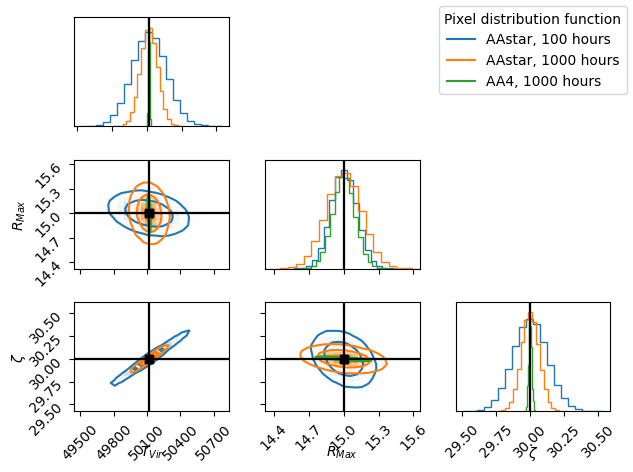

In [7]:
fig, axes = plt.subplots(nparams, nparams)
for j, (obs_time, layout) in enumerate(zip(obs_time_array, layout_array)):
    covmat = np.loadtxt(f'./output/posterior_covariance_matrix_{layout}_{int(obs_time)}hours_pdf.txt')
    fisher_data = np.random.multivariate_normal(fid, covmat, size=nrand)
    _ = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truth_color='k',
    truths=fid,
    color=f'C{j}',
    fig=fig)
    axes[0, 0].plot([], [], label=f'{layout}, {int(obs_time)} hours', color=f'C{j}', linestyle='-')
fig.legend(loc='upper right', fontsize=10, title='Pixel distribution function')
fig.tight_layout()

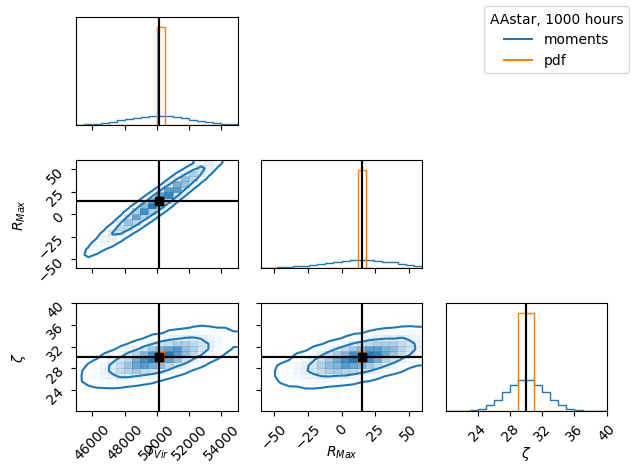

In [ ]:
obs_time = 1000.
layout = 'AAstar'

fig, axes = plt.subplots(nparams, nparams)
for j, statname in enumerate(['moments', 'pdf']):
    covmat = np.loadtxt(f'./output/posterior_covariance_matrix_{layout}_{int(obs_time)}hours_{statname}.txt')
    fisher_data = np.random.multivariate_normal(fid, covmat, size=nrand)
    _ = corner.corner(
    fisher_data,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truth_color='k',
    truths=fid,
    color=f'C{j}',
    alpha=.6,
    range=[(45e3, 55e3), (-60, 60), (20, 40)],
    fig=fig)
    axes[0, 0].plot([], [], label=statname, color=f'C{j}', linestyle='-')
fig.legend(loc='upper right', fontsize=10, title=f'{layout}, {int(obs_time)} hours')
fig.tight_layout()